# Constraint cosmological parameters and cosmic baryons

In [1]:
import sys
sys.path.append('../Python_scripts')
from tqdm import tqdm

## Import packages
from config import *
from support import *
from cosmo_support import *

Show data

In [2]:
data=pd.read_csv('../Data/FRB.csv')
data

,FRB,z,DM_ext
0,FRB 20180814A,0.06800,73.30
1,FRB 20181030A,0.00385,32.30
2,FRB 20220529A,0.18390,176.00
3,FRB 20220610A,1.01600,1397.15
4,FRB 20220717A,0.36295,489.04
...,...,...,...
112,FRB 20231204A,0.06440,159.94
113,FRB 20231206A,0.06590,370.12
114,FRB 20231223C,0.10590,87.07
115,FRB 20231229A,0.01900,110.98


In [3]:
# print(data[data['FRB'] == 'FRB 20190520B'])
# print(data[data['FRB'] == 'FRB 20220831A'])

In [4]:
print(len(data))
data = data[data['FRB'] != 'FRB 20190520B']
data = data[data['FRB'] != 'FRB 20220831A']
data = data[data['z'] >= 0.05]
print(len(data))
data.head()

117
99


,FRB,z,DM_ext
0,FRB 20180814A,0.06800,73.30
2,FRB 20220529A,0.18390,176.00
3,FRB 20220610A,1.01600,1397.15
4,FRB 20220717A,0.36295,489.04
6,FRB 20230521B,1.35400,1174.10


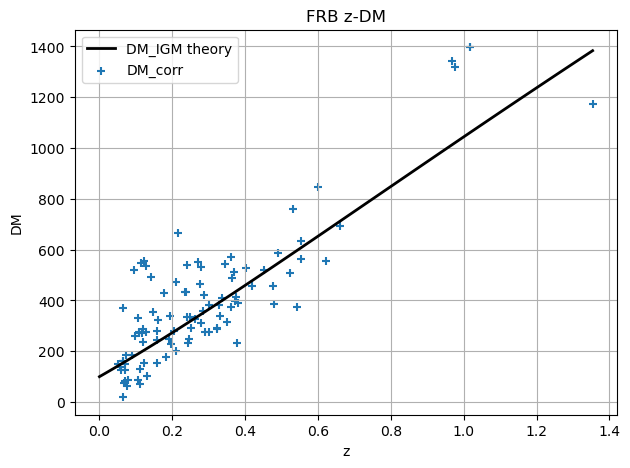

In [5]:
fig = plt.figure(figsize=(7,5))
ax1 = fig.add_subplot(111)

z_range = np.linspace(0, np.max(data['z']), 100)

DM_theory = np.zeros_like(z_range)
for idx, redshift in enumerate(z_range):
    DM_theory[idx] = dispersion_measure(redshift, H0=HUBBLE, Om=OMEGA_MATTER, w=-1, alpha=0.11, f_IGM_0 = f_IGM)

ax1.plot(z_range, 100+DM_theory, lw=2, c='black', label='DM_IGM theory')
ax1.scatter(data['z'], data['DM_ext'], s=40, marker='+', label='DM_corr')  
ax1.set_xlabel('z')
ax1.set_ylabel('DM')
ax1.set_title('FRB z-DM')
ax1.grid(True)
ax1.legend()


plt.show()

search F range 

In [6]:
F_array=np.linspace(0.01, 1.0, 20)
sigma_host_array=np.linspace(0.2,1.4,20)
e_mu_array=np.linspace(50, 250, 20)

PDF preparation

In [7]:
z_min=np.min(data['z'])
z_max=np.max(data['z'])
F_min=np.min(F_array)
F_max=np.max(F_array)
sigmas=[f_sigma_DM(F_min,z_min),f_sigma_DM(F_max,z_min),f_sigma_DM(F_max,z_max),f_sigma_DM(F_min,z_max)]
sigma_min=np.min(sigmas)
sigma_max=np.max(sigmas)
print([sigma_min,sigma_max])

[0.011680659976878524, 20.49593431428785]


In [8]:
sigma_rsl=200
# sigmas=np.linspace(sigma_min, sigma_max, sigma_rsl)
sigmas=np.linspace(sigma_min, 58, sigma_rsl)
print([np.min(sigmas),np.max(sigmas)])
C0s=np.zeros_like(sigmas)

for i, sigma in enumerate(sigmas):
    C0s[i]=C0_sigma(sigma)

[0.011680659976878524, 58.0]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


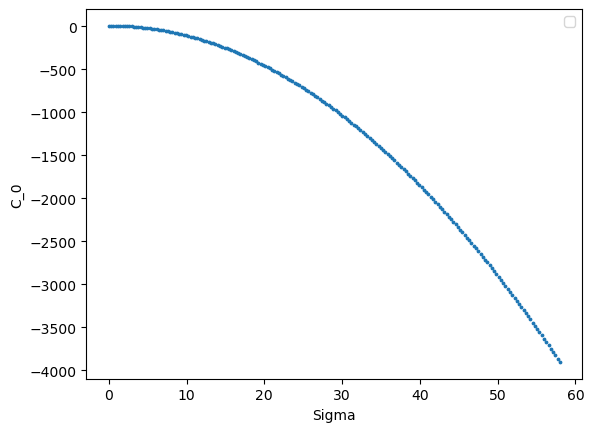

In [9]:
plt.scatter(sigmas, C0s,  s=3)

plt.ylabel('C_0')
plt.xlabel('Sigma')
plt.legend()

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


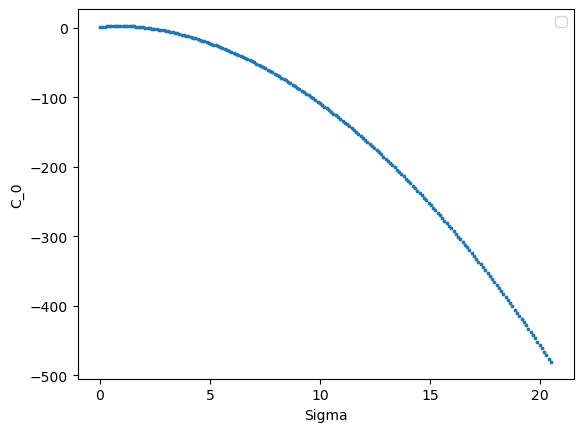

In [10]:
DM_sigma = interpolate.interp1d(sigmas, C0s, kind='cubic',bounds_error=False, fill_value='extrapolate')

test_sigmas=np.linspace(sigma_min, sigma_max, sigma_rsl)
test_C0s=np.zeros_like(test_sigmas)


for i, sigma in enumerate(test_sigmas):
    test_C0s[i]=DM_sigma(sigma)
    
plt.scatter(test_sigmas, test_C0s,  s=3)

plt.ylabel('C_0')
plt.xlabel('Sigma')
plt.legend()

plt.show()

In [11]:
# F=0.01
# z=0.011
# delta_array=np.linspace(0.01,C_0*100,500)
# p=np.zeros_like(delta_array)
# for i,delta in enumerate(delta_array):
#     sigmat=f_sigma_DM(F,z,met='new')
#     C_0=find_C0(F, z, sigmas, C0s, alpha=3, beta=3, sigma_met="new",method="interpolation", x_min=0, x_max=np.inf)
#     p[i]=pdf_DM_cosmo(delta, C_0, 1, sigma=sigmat, alpha=3, beta=3)
    
# plt.scatter(delta_array, p, s=3)

# plt.ylabel('p')
# plt.xlabel('delta')
# plt.legend()

# plt.show()

Constrain $H_0 \Omega_0 f_{IGM}=const $

In [12]:
def DM_IGM_H0_O_b_f_IGM(z, H0_O_b_f_IGM, Om=OMEGA_MATTER, w=-1):
    
    def integrand(z, Om, w):
        return (1+z)/np.sqrt(Om*(1+z)**3+(1-Om)*(1+z)**(3*(1+w)))

    factor = 3*C_LIGHT*H0_O_b_f_IGM/(8*PI*G_NEWTON*M_PROTON)*(7/8)
    
    integral, _ = quad(integrand, 0, z, args=(Om, w))
    
    unit_transform = DM_2_PCCM3*KM_2_MPC
    
    DM = unit_transform*factor*integral
    
    return DM

In [13]:
z=1.00
print(DM_IGM_O_bh_70(z=z, O_bh_70=OMEGA_BARYONS*HUBBLE/70.0))
print(DM_IGM_H0_O_b_f_IGM(z=z, H0_O_b_f_IGM=HUBBLE*OMEGA_BARYONS*f_IGM))

944.0949564541271
912.8582288974072


In [14]:
def calculate_dm_probability_num_HOf_v2(DM_frb_max, z, F, HOf, e_mu, sigma_host):
    
    ## Cosmic calculation    
    DM_th = DM_IGM_H0_O_b_f_IGM(z=z, H0_O_b_f_IGM=HOf, Om=OMEGA_MATTER, w=-1)
    
    Delta_array = np.linspace(0.01, DM_frb_max / DM_th-0.01, 5000)
    
    C_0=find_C0(F=F, z=z, sigmas=sigmas, C0s=C0s)
    A = find_A(C_0=C_0, F=F, z=z, alpha=3, beta=3)
    pdf_cosmic = pdf_DM_cosmo(Delta_array, C_0, A=A, sigma=f_sigma_DM(F,z))
    
    ## Host calculation
    pdf_host = pdf_DM_host((1+z)*(DM_frb_max-DM_th * Delta_array), e_mu, sigma_host)
    
    ## Combine together    
    prob = np.trapz(pdf_host*pdf_cosmic, x=Delta_array)
    
    ## Transform to probabilities
    # dDM = np.abs(np.diff(DM_frb_array)[0])/DM_IGM_O_bh_70(z=z, O_bh_70=O_bh_70, Om=OMEGA_MATTER, w=-1,alpha=0)/(1+z)
    
    return prob*(1+z)

In [15]:
def calculate_dm_probability_num_HOf(DM_frb_max, z, F, HOf, e_mu, sigma_host):
    
    DM_host_array = np.linspace(0.01, DM_frb_max * (1+z)-0.01, 5000)

    ## Host calculation
    pdf_host = pdf_DM_host(DM_host_array, e_mu, sigma_host)
    
    ## Cosmic calculation    
    DM_th = DM_IGM_H0_O_b_f_IGM(z=z, H0_O_b_f_IGM=HOf, Om=OMEGA_MATTER, w=-1)
    Deltas = (DM_frb_max-DM_host_array/(1+z))/DM_th
    C_0=find_C0(F=F, z=z, sigmas=sigmas, C0s=C0s)
    A = find_A(C_0=C_0, F=F, z=z, alpha=3, beta=3)
    pdf_cosmic = pdf_DM_cosmo(Deltas, C_0, A=A, sigma=f_sigma_DM(F,z))
    
    ## Combine together    
    prob = np.trapz(pdf_host*pdf_cosmic, x=DM_host_array)
    
    ## Transform to probabilities
    # dDM = np.abs(np.diff(DM_frb_array)[0])/DM_IGM_O_bh_70(z=z, O_bh_70=O_bh_70, Om=OMEGA_MATTER, w=-1,alpha=0)/(1+z)
    
    return prob/DM_th

In [16]:
# DM_frb_max=134
# z=0.157
# F=1.0
# HOf=3.0
# e_mu=200
# sigma_host=1.5

# print(calculate_dm_probability_num_HOf(DM_frb_max, z, F, HOf, e_mu, sigma_host))
# print(calculate_dm_probability_num_HOf_v2(DM_frb_max, z, F, HOf, e_mu, sigma_host))

In [17]:
HOf_fiducial=70*OMEGA_BARYONS*0.9
print(HOf_fiducial)

3.0851100000000002


In [18]:
# F defined before
HOf_array=np.linspace(1.0, 5.0, 40)

F_4D, HOf_array_4D, sigma_host_4D, e_mu_4D = np.meshgrid(
    F_array, HOf_array, sigma_host_array, e_mu_array,
    indexing='ij'
    )

F_h, h_F = np.meshgrid(F_array, HOf_array)
F_sigma, sigma_F = np.meshgrid(F_array, sigma_host_array)
F_e_mu, e_mu_F = np.meshgrid(F_array, e_mu_array)

h_sigma, sigma_h = np.meshgrid(HOf_array, sigma_host_array)
h_e_mu, e_mu_h = np.meshgrid(HOf_array, e_mu_array)

sigma_e_mu, e_mu_sigma = np.meshgrid(sigma_host_array, e_mu_array)

print(fr'Shape of F_4D: {F_4D.shape}, HOf_array_4D: {HOf_array_4D.shape}, sigma_host_4D: {sigma_host_4D.shape}, e_mu_4D: {e_mu_4D.shape}')
print(fr'Shape of F_h: {F_h.shape}, h_F: {h_F.shape}, F_sigma: {F_sigma.shape}, sigma_F: {sigma_F.shape}, F_e_mu: {F_e_mu.shape}, e_mu_F: {e_mu_F.shape}')

Shape of F_4D: (20, 40, 20, 20), HOf_array_4D: (20, 40, 20, 20), sigma_host_4D: (20, 40, 20, 20), e_mu_4D: (20, 40, 20, 20)
Shape of F_h: (40, 20), h_F: (40, 20), F_sigma: (20, 20), sigma_F: (20, 20), F_e_mu: (20, 20), e_mu_F: (20, 20)


In [19]:
# posterior_4D = 1.0 + np.zeros_like(F_4D, dtype= np.float128)
log_posterior_4D = np.zeros_like(F_4D, dtype= np.float64)
# Calculate total iterations for progress bar
# total_iterations = len(data['FRB']) * len(F_array) * len(HOf_array) * len(sigma_host_array) * len(e_mu_array)
total_iterations = len(data['FRB'])

# Create flattened parameter combinations
param_combinations = [
    (F, HOf, sigma_host, e_mu)
    for F in F_array
    for HOf in HOf_array
    for sigma_host in sigma_host_array
    for e_mu in e_mu_array
]

# Initialize progress bar
pbar = tqdm(total=total_iterations, desc='Computing posteriors')
    
# Calculate and accumulate probabilities for each FRB
for _, row in data.iterrows():
    # Iterate through parameter combinations
    for idx, (F, HOf, sigma_host, e_mu) in enumerate(param_combinations):
        prob = calculate_dm_probability_num_HOf_v2(
            DM_frb_max=row['DM_ext'],
            z=row['z'],
            F=F,
            HOf=HOf,
            sigma_host=sigma_host,
            e_mu=e_mu
        )
        
        # Calculate indices for 4D array
        i = idx // (len(HOf_array) * len(sigma_host_array) * len(e_mu_array))
        j = (idx % (len(HOf_array) * len(sigma_host_array) * len(e_mu_array))) // (len(sigma_host_array) * len(e_mu_array))
        k = (idx % (len(sigma_host_array) * len(e_mu_array))) // len(e_mu_array)
        l = idx % len(e_mu_array)
    
        # Store result
        # print([i,j,k,l])
        # posterior_4D[i,j,k,l] = posterior_4D[i,j,k,l] * prob
        if prob > 0:
            log_posterior_4D[i,j,k,l] += np.log(prob)
        else:
            # print(f"Inputs: DM_frb_max={row['DM_ext']}, z={row['z']}, F={F}, HOf={HOf}, sigma_host={sigma_host}, e_mu={e_mu}")
            log_posterior_4D[i,j,k,l] = -np.inf
        
        # Update progress bar
        # pbar.update(1)
    
        # Optional: Add parameter values to progress bar description
        # pbar.set_description(f"idx={_}, FRB={row['FRB']}, F={F:.2f}, HOf={HOf:.2f}, σ={sigma_host:.2f}, μ={e_mu:.2f}")
    
    # # log_posterior = np.log(posterior_4D)
    log_sum = np.logaddexp.reduce(log_posterior_4D.ravel())
    if np.isfinite(log_sum):
        log_posterior_4D = log_posterior_4D - log_sum
    else:
        print(f"Warning: posterior sum is zero for FRB={row['FRB']}")
        break
            
    # posterior_4D_tot=np.sum(posterior_4D)
    # if posterior_4D_tot>0:
    #     posterior_4D=posterior_4D/posterior_4D_tot
    # else:
    #     print(f"posterior_4D_tot={posterior_4D_tot} at FRB={row['FRB']}")
    #     break
    
    pbar.update(1)
    pbar.set_description(f"FRB={row['FRB']}")

# Close progress bar
pbar.close()

Computing posteriors:   0%|          | 0/99 [00:00<?, ?it/s]

FRB=FRB 20231223C: 100%|██████████| 99/99 [12:26:29<00:00, 452.42s/it]  


In [20]:
log_sum = np.logaddexp.reduce(log_posterior_4D.ravel())
if np.isfinite(log_sum):
    posterior_4D = np.exp(log_posterior_4D - log_sum)
else:
    print(f"Warning: posterior sum is zero")

np.save("./posterior/posterior_4D.npy", posterior_4D)

In [21]:
posterior_4D = np.load("./posterior/posterior_4D.npy")

/var/folders/9w/bbgy16c17_g3tqprqy1t6jcr0000gn/T/ipykernel_29182/666578381.py:22: RuntimeWarning: divide by zero encountered in log
  delta_chi2 = -2 * np.log(marginal_prob)


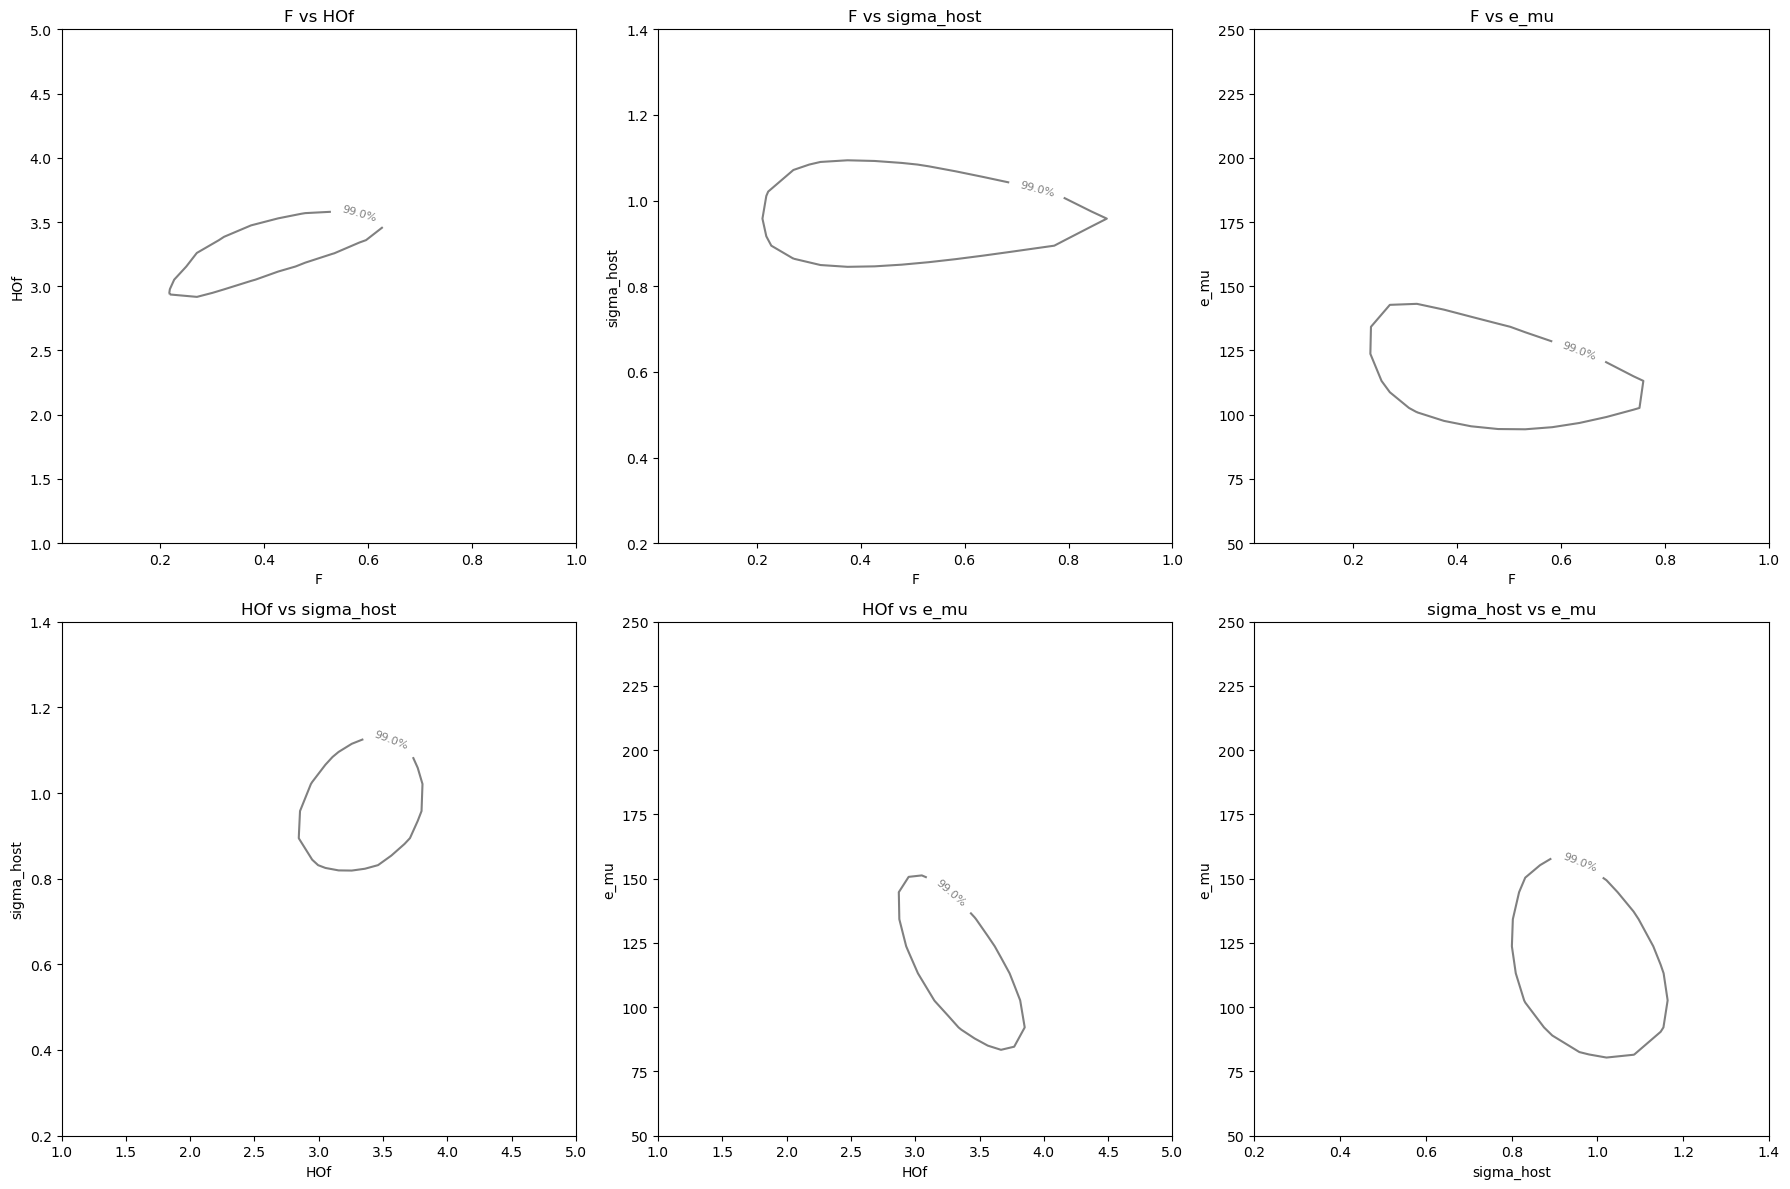

In [22]:
from scipy.stats import chi2

confidence_levels = [0.1,0.3,0.5,0.68, 0.95, 0.99]
contour_levels = [chi2.ppf(cl, df=2) for cl in confidence_levels]

grid_pairs = [
    ("F", "HOf", (2, 3), F_h, h_F),
    ("F", "sigma_host", (1, 3), F_sigma, sigma_F),
    ("F", "e_mu", (1, 2), F_e_mu, e_mu_F),
    ("HOf", "sigma_host", (0, 3), h_sigma, sigma_h),
    ("HOf", "e_mu", (0, 2), h_e_mu, e_mu_h),
    ("sigma_host", "e_mu", (0, 1), sigma_e_mu, e_mu_sigma)
]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (x_var, y_var, marginal_axes, X, Y) in enumerate(grid_pairs):
    marginal_prob = np.sum(posterior_4D, axis=marginal_axes)
    marginal_prob = marginal_prob/np.sum(marginal_prob)
    
    delta_chi2 = -2 * np.log(marginal_prob)
    
    ax = axes[idx]
    cs = ax.contour(X, Y, delta_chi2.T, levels=contour_levels, colors=['r', 'b', 'g', 'orange', 'magenta', 'grey'])
    
    ax.set_xlabel(x_var)
    ax.set_ylabel(y_var)
    ax.set_title(f"{x_var} vs {y_var}")
    
    fmt = {contour_levels[0]: f'{confidence_levels[0]*100}%', 
           contour_levels[1]: f'{confidence_levels[1]*100}%',
           contour_levels[2]: f'{confidence_levels[2]*100}%',
           contour_levels[3]: f'{confidence_levels[3]*100}%',
           contour_levels[4]: f'{confidence_levels[4]*100}%',
           contour_levels[5]: f'{confidence_levels[5]*100}%'}
    ax.clabel(cs, cs.levels, inline=True, fmt=fmt, fontsize=8)

plt.tight_layout()
plt.show()

Constrain $H_0 \Omega_0 f_{IGM}=H_0 \Omega_0 f_{IGM,0}(1+a
\cdot z)$

In [23]:
def DM_IGM_H0_O_b_f_IGM_linear(z, H0_O_b_f_IGM, a, Om=OMEGA_MATTER, w=-1):
    
    def integrand(z, a, Om, w):
        #return (1+z)/np.sqrt(Om*(1+z)**3+(1-Om)*(1+z)**(3*(1+w)))
        return (1+a*z)*(1+z)/np.sqrt(Om*(1+z)**3+(1-Om)*(1+z)**(3*(1+w)))

    factor = 3*C_LIGHT*KM_2_MPC*H0_O_b_f_IGM/(8*PI*G_NEWTON*M_PROTON)*(7/8)
    
    
    integral, _ = quad(integrand, 0, z, args=(a, Om, w))
    
    unit_transform = DM_2_PCCM3
    
    DM = unit_transform*factor*integral
    
    return DM

In [24]:
def calculate_dm_probability_num_HOf_linear(DM_frb_max, z, F, HOf, a ,sigma_host, e_mu):
    
    DM_host_array = np.linspace(0.01, DM_frb_max * (1+z)-0.01, 5000)

    ## Host calculation
    pdf_host = pdf_DM_host(DM_host_array, e_mu, sigma_host)
    # print(pdf_host)
    
    ## Cosmic calculation    
    DM_th = DM_IGM_H0_O_b_f_IGM_linear(z=z, H0_O_b_f_IGM=HOf, a=a, Om=OMEGA_MATTER, w=-1)
    Deltas = (DM_frb_max-DM_host_array/(1+z))/DM_th
    C_0=find_C0(F=F, z=z, sigmas=sigmas, C0s=C0s)
    A = find_A(C_0=C_0, F=F, z=z, alpha=3, beta=3)
    pdf_cosmic = pdf_DM_cosmo(Deltas, C_0, A=A, sigma=f_sigma_DM(F,z))
    # print(pdf_cosmic)
    
    ## Combine together    
    prob = np.trapz(pdf_host*pdf_cosmic, x=DM_host_array)
    
    ## Transform to probabilities
    # dDM = np.abs(np.diff(DM_frb_array)[0])/DM_IGM_O_bh_70(z=z, O_bh_70=O_bh_70, Om=OMEGA_MATTER, w=-1,alpha=0)/(1+z)
    
    return prob/DM_th

In [25]:
# 176.0, 0.1839, 0.01, 1.5555555555555556, 0.3566666666666667, 0.01, 200.0

calculate_dm_probability_num_HOf_linear(281.42, 0.3214, 0.2,3.3, 0.02 ,0.8, 130)

0.003343310221388296

In [26]:
F_array=np.linspace(0.01, 1.6, 10)
sigma_host_array=np.linspace(0.2,1.6,10)
e_mu_array=np.linspace(50, 250, 10)
HOf_array=np.linspace(1.0,5.0, 10)
a_array=np.linspace(0, 0.4, 10)

F_5D, HOf_array_5D, a_array_5D, sigma_host_5D, e_mu_5D = np.meshgrid(
    F_array, HOf_array, a_array, sigma_host_array, e_mu_array,
    indexing='ij'
    )

F_h, h_F = np.meshgrid(F_array, HOf_array)
F_a, a_F = np.meshgrid(F_array, a_array)
F_sigma, sigma_F = np.meshgrid(F_array, sigma_host_array)
F_e_mu, e_mu_F = np.meshgrid(F_array, e_mu_array)

h_a, a_h = np.meshgrid(HOf_array, a_array)
h_sigma, sigma_h = np.meshgrid(HOf_array, sigma_host_array)
h_e_mu, e_mu_h = np.meshgrid(HOf_array, e_mu_array)

a_sigma, sigma_a = np.meshgrid(a_array, sigma_host_array)
a_e_mu, e_mu_a = np.meshgrid(a_array, e_mu_array)

sigma_e_mu, e_mu_sigma = np.meshgrid(sigma_host_array, e_mu_array)

print(fr'Shape of F_5D: {F_5D.shape}, HOf_array_5D: {HOf_array_5D.shape}, a_array_5D: {a_array_5D.shape}, sigma_host_5D: {sigma_host_5D.shape}, e_mu_5D: {e_mu_5D.shape}')
print(fr'Shape of F_h: {F_h.shape}, h_F: {h_F.shape}, F_a: {F_a.shape}, a_F: {a_F.shape}, F_sigma: {F_sigma.shape}, sigma_F: {sigma_F.shape}, F_e_mu: {F_e_mu.shape}, e_mu_F: {e_mu_F.shape}')

Shape of F_5D: (10, 10, 10, 10, 10), HOf_array_5D: (10, 10, 10, 10, 10), a_array_5D: (10, 10, 10, 10, 10), sigma_host_5D: (10, 10, 10, 10, 10), e_mu_5D: (10, 10, 10, 10, 10)
Shape of F_h: (10, 10), h_F: (10, 10), F_a: (10, 10), a_F: (10, 10), F_sigma: (10, 10), sigma_F: (10, 10), F_e_mu: (10, 10), e_mu_F: (10, 10)


In [27]:
# posterior_5D = 1.0 + np.zeros_like(F_5D, dtype= np.float128)
log_posterior_5D = np.zeros_like(F_5D, dtype= np.float64)
# Calculate total iterations for progress bar
# total_iterations = len(data['FRB']) * len(F_array) * len(HOf_array) * len(a_array) * len(sigma_host_array) * len(e_mu_array)
total_iterations = len(data['FRB'])

# Create flattened parameter combinations
param_combinations = [
    (F, HOf, a, sigma_host, e_mu)
    for F in F_array
    for HOf in HOf_array
    for a in a_array
    for sigma_host in sigma_host_array
    for e_mu in e_mu_array
]

# Initialize progress bar
pbar = tqdm(total=total_iterations, desc='Computing posteriors')
    
# Calculate and accumulate probabilities for each FRB
for _, row in data.iterrows():
    # Iterate through parameter combinations
    for idx, (F, HOf, a, sigma_host, e_mu) in enumerate(param_combinations):
        prob = calculate_dm_probability_num_HOf_linear(
            DM_frb_max=row['DM_ext'],
            z=row['z'],
            F=F,
            HOf=HOf,
            a=a,
            sigma_host=sigma_host,
            e_mu=e_mu
        )
        if (prob>10):
            print(f"Inputs: p={prob}, DM_frb_max={row['DM_ext']}, z={row['z']}, F={F}, HOf={HOf}, a={a}, sigma_host={sigma_host}, e_mu={e_mu}")
            #print([row['DM_ext'],row['z'],F,HOf,a,sigma_host,e_mu])
            break
        
        # Calculate indices for 5D array
        i = idx // (len(HOf_array) * len(a_array) * len(sigma_host_array) * len(e_mu_array))
        j = (idx % (len(HOf_array) * len(a_array) * len(sigma_host_array) * len(e_mu_array))) // (len(a_array) * len(sigma_host_array) * len(e_mu_array))
        k = (idx % (len(a_array) * len(sigma_host_array) * len(e_mu_array))) // (len(sigma_host_array) * len(e_mu_array))
        l = (idx % (len(sigma_host_array) * len(e_mu_array))) // len(e_mu_array)
        m = idx % len(e_mu_array)
    
        # Store result
        # posterior_5D[i,j,k,l,m] = posterior_5D[i,j,k,l,m] * prob
        
        # if (F != F_array[i] or HOf !=HOf_array[j] or a != a_array[k] or sigma_host != sigma_host_array[l] or e_mu != e_mu_array[m]):
        #     print([i,j,k,l,m])
        #     #print(f"F={F},HOf={HOf},a={a},sigma_host={sigma_host},e_mu={e_mu}")
        #     print([F,HOf,a,sigma_host,e_mu])
        #     print([F_array[i],HOf_array[j],a_array[k],sigma_host_array[l],e_mu_array[m]])
            
        if prob > 0:
            log_posterior_5D[i,j,k,l,m] += np.log(prob)
        else:
            # print(f"Inputs: DM_frb_max={row['DM_ext']}, z={row['z']}, F={F},HOf={HOf},a={a},sigma_host={sigma_host},e_mu={e_mu}")
            # print([i,j,k,l,m])
            # print([F_array[i],HOf_array[j],a_array[k],sigma_host_array[l],e_mu_array[m]])
            log_posterior_5D[i,j,k,l,m] = -np.inf
        
        # # Update progress bar
        # pbar.update(1)
    
        # # Optional: Add parameter values to progress bar description
        # pbar.set_description(f"idx={_}, FRB={row['FRB']}, F={F:.2f}, HOf={HOf:.2f}, a={a:.2f}, σ={sigma_host:.2f}, μ={e_mu:.2f}")
    
    log_sum = np.logaddexp.reduce(log_posterior_5D.ravel())
    if np.isfinite(log_sum):
        posterior_5D = np.exp(log_posterior_5D - log_sum)
    else:
        print(f"Warning: posterior sum is zero for FRB={row['FRB']}")
        break
    
    # posterior_5D_tot=np.sum(posterior_5D)
    # if posterior_5D_tot>0:
    #     posterior_5D=posterior_5D/posterior_5D_tot
    # else:
    #     print(f"posterior_5D_tot={posterior_5D_tot} at FRB={row['FRB']}")
    #     break
    
    pbar.update(1)
    pbar.set_description(f"FRB={row['FRB']}")
    # break

# Close progress bar
pbar.close()

FRB=FRB 20231223C: 100%|██████████| 99/99 [3:46:57<00:00, 137.55s/it]  


In [28]:
log_sum = np.logaddexp.reduce(log_posterior_5D.ravel())
print(log_sum)
if np.isfinite(log_sum):
    posterior_5D = np.exp(log_posterior_5D - log_sum)
else:
    print(f"Warning: posterior sum is zero")

np.save("./posterior/posterior_5D.npy", posterior_5D)

-633.6398188467908


In [29]:
posterior_5D = np.load("./posterior/posterior_5D.npy")
print(np.sum(posterior_5D))

1.0000000000331923


In [30]:
print(log_posterior_5D[5,5,:,5,5])

[-644.95571654 -644.63878203 -644.34193972 -644.06575888 -643.81088277
 -643.5780301  -643.36799677 -643.181658   -643.01997069 -642.88397601]


In [31]:
print(posterior_5D[5,5,:,5,5])

[1.21777786e-05 1.67190264e-05 2.24971737e-05 2.96532142e-05
 3.82615942e-05 4.82936127e-05 5.95807562e-05 7.17847030e-05
 8.43823890e-05 9.66748604e-05]


/var/folders/9w/bbgy16c17_g3tqprqy1t6jcr0000gn/T/ipykernel_29182/1337276825.py:26: RuntimeWarning: divide by zero encountered in log
  delta_chi2 = -2 * np.log(marginal_prob / np.max(marginal_prob))


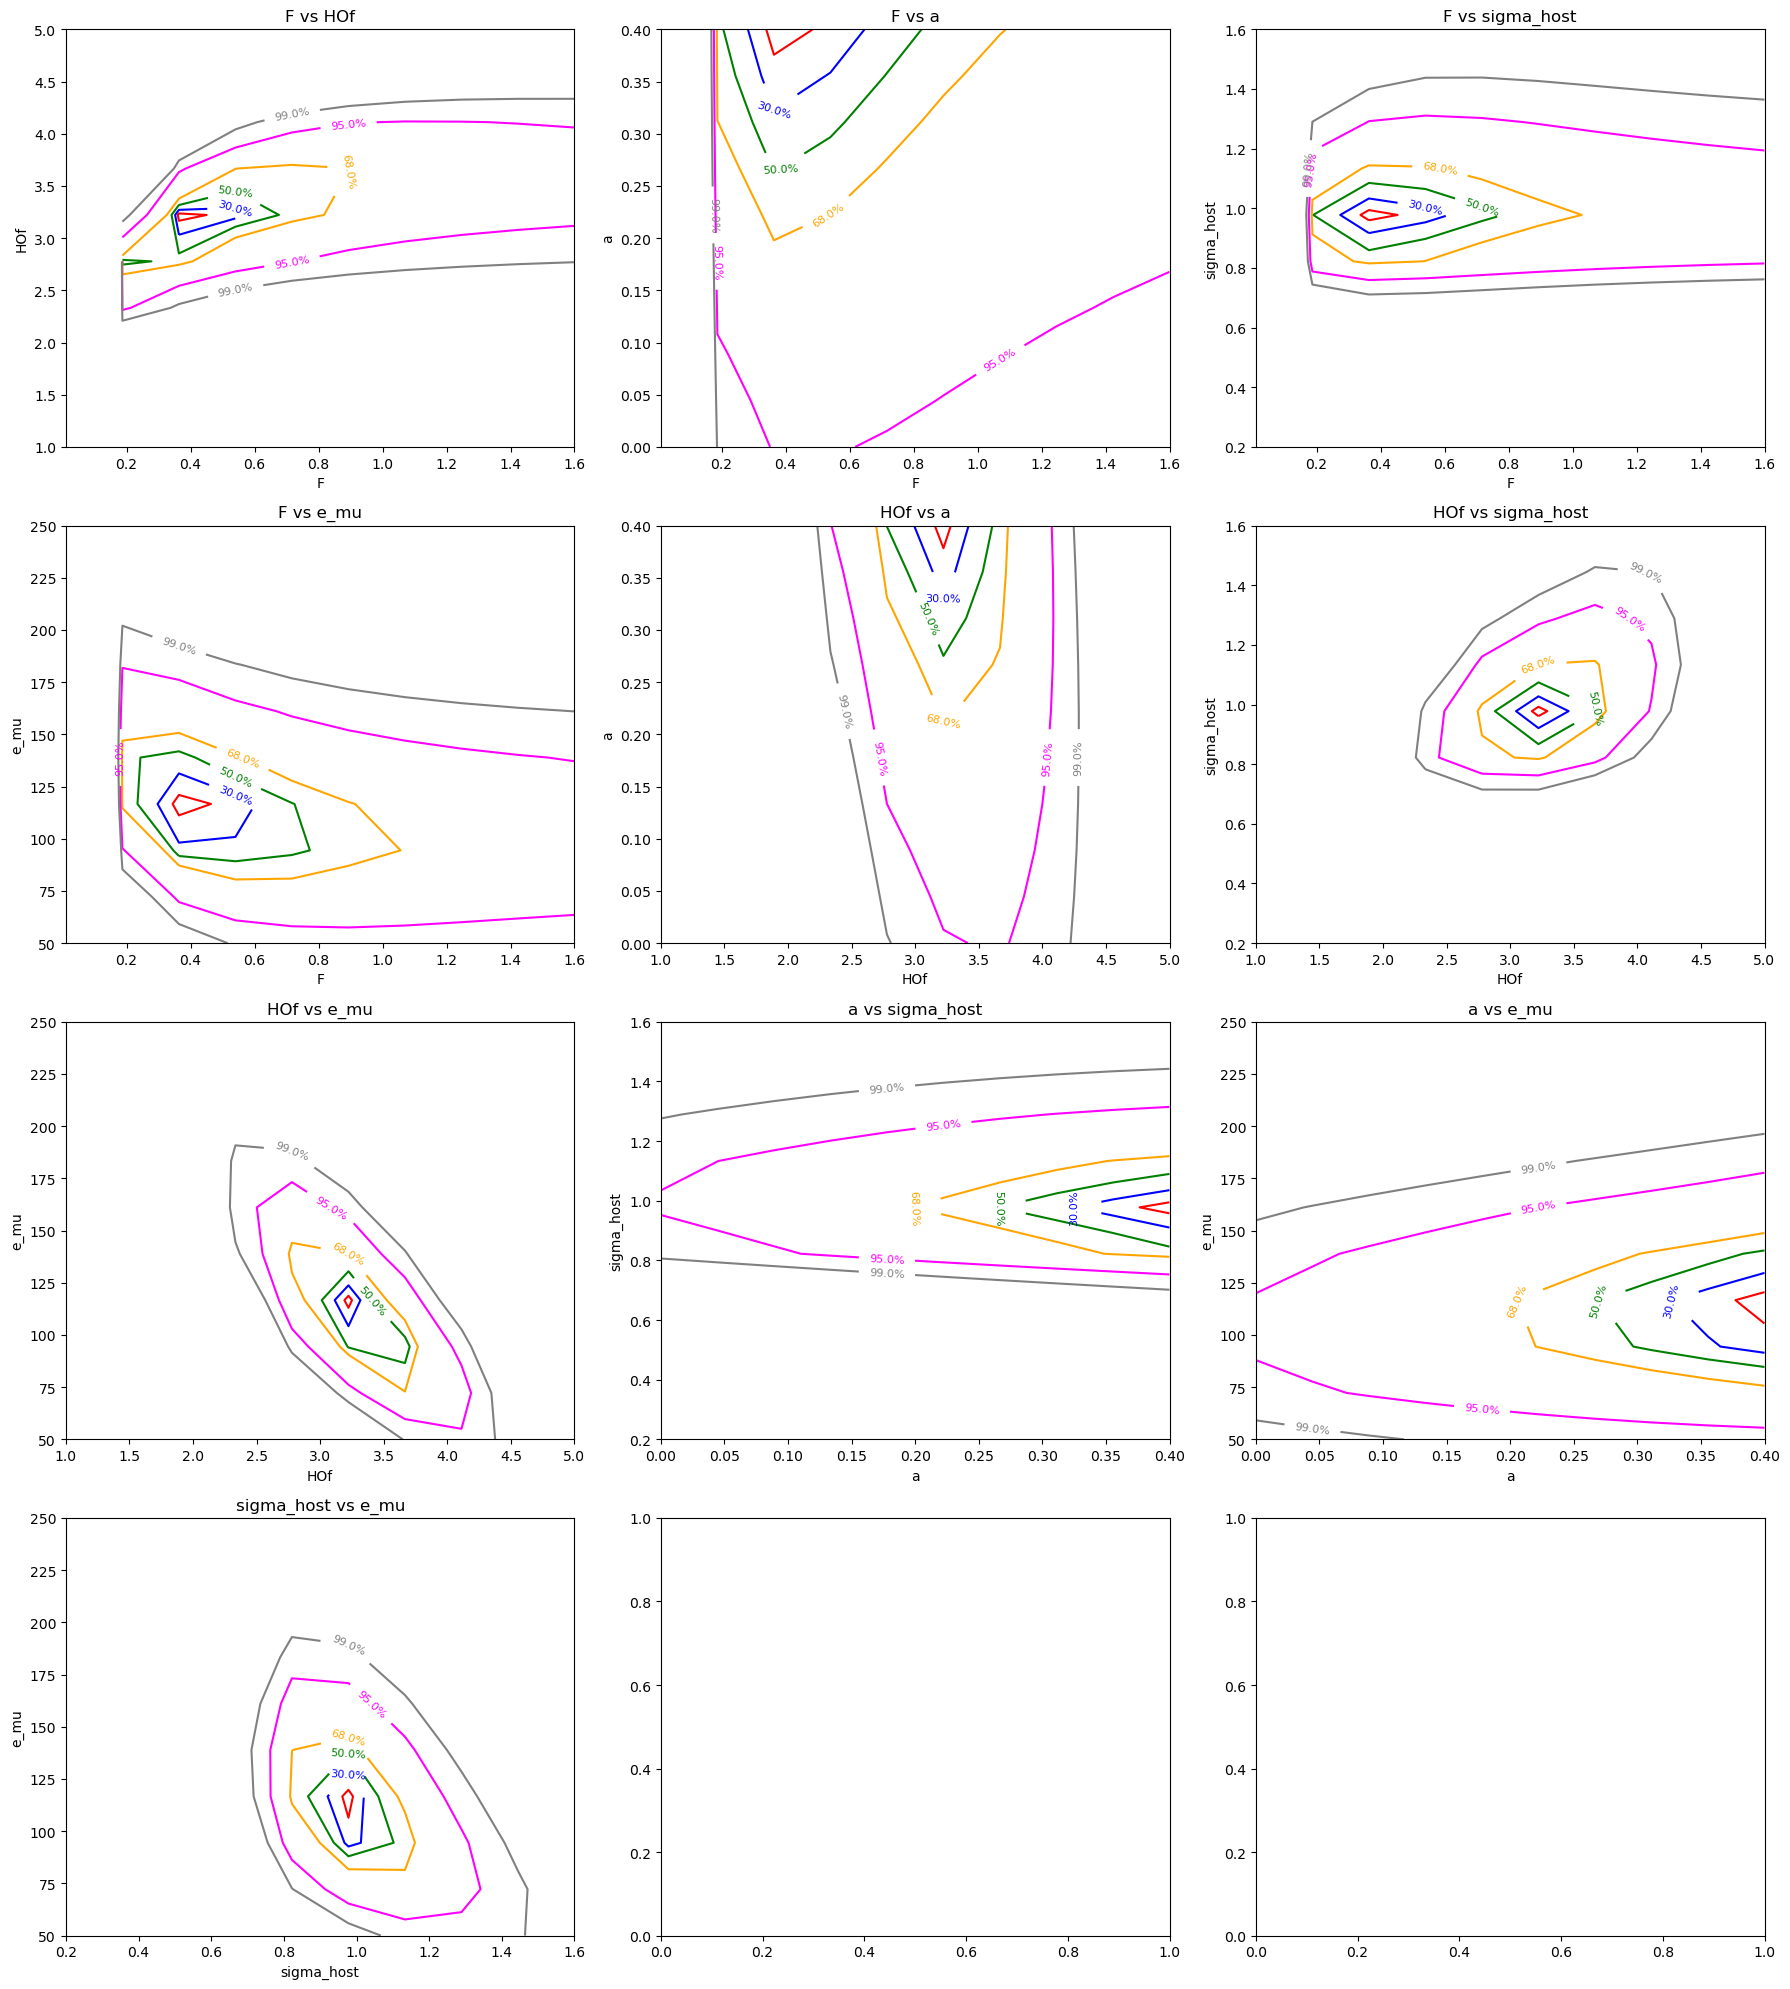

In [32]:
from scipy.stats import chi2

confidence_levels = [0.1,0.3,0.5,0.68, 0.95, 0.99]
contour_levels = [chi2.ppf(cl, df=2) for cl in confidence_levels]

grid_pairs = [
    ("F", "HOf", (2, 3, 4), F_h, h_F),
    ("F", "a", (1, 3, 4), F_a, a_F),
    ("F", "sigma_host", (1, 2, 4), F_sigma, sigma_F),
    ("F", "e_mu", (1, 2, 3), F_e_mu, e_mu_F),
    ("HOf", "a", (0, 3, 4), h_a, a_h),
    ("HOf", "sigma_host", (0, 2, 4), h_sigma, sigma_h),
    ("HOf", "e_mu", (0, 2, 3), h_e_mu, e_mu_h),
    ("a", "sigma_host", (0, 1, 4), a_sigma, sigma_a),
    ("a", "e_mu", (0, 1, 3), a_e_mu, e_mu_a),
    ("sigma_host", "e_mu", (0, 1, 2), sigma_e_mu, e_mu_sigma)
]

fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

for idx, (x_var, y_var, marginal_axes, X, Y) in enumerate(grid_pairs):
    marginal_prob = np.sum(posterior_5D, axis=marginal_axes)
    marginal_prob = marginal_prob/np.sum(marginal_prob)
    
    delta_chi2 = -2 * np.log(marginal_prob / np.max(marginal_prob))
    
    ax = axes[idx]

    cs = ax.contour(X, Y, delta_chi2.T, levels=contour_levels, colors=['r', 'b', 'g', 'orange', 'magenta', 'grey'])
    
    ax.set_xlabel(x_var)
    ax.set_ylabel(y_var)
    ax.set_title(f"{x_var} vs {y_var}")
    
    fmt = {contour_levels[0]: f'{confidence_levels[0]*100}%', 
           contour_levels[1]: f'{confidence_levels[1]*100}%',
           contour_levels[2]: f'{confidence_levels[2]*100}%',
           contour_levels[3]: f'{confidence_levels[3]*100}%',
           contour_levels[4]: f'{confidence_levels[4]*100}%',
           contour_levels[5]: f'{confidence_levels[5]*100}%'}
    ax.clabel(cs, cs.levels, inline=True, fmt=fmt, fontsize=8)

plt.tight_layout()
plt.show()